<a href="https://colab.research.google.com/github/amallindask/data-science-2026/blob/main/Pertemuan5_Amallinda_250401020003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DASHBOARD VISUALISASI STATIS

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [32]:
# 1. LOAD & INSPECT DATASET

df = sns.load_dataset('tips')
print(df.shape, df.dtypes)
print('\n',df.describe().round(2))

(244, 7) total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

        total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


In [33]:
#LOAD DATASET
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [43]:
# 2. SETUP FIGURE LAYOUT
fig = plt.figure(figsize=(16,12))
fig.suptitle('Dashboard Analisis Dataset Tips',
             fontsize=18, fontweight='bold',y=0.98)


Text(0.5, 0.98, 'Dashboard Analisis Dataset Tips')

<Figure size 1600x1200 with 0 Axes>

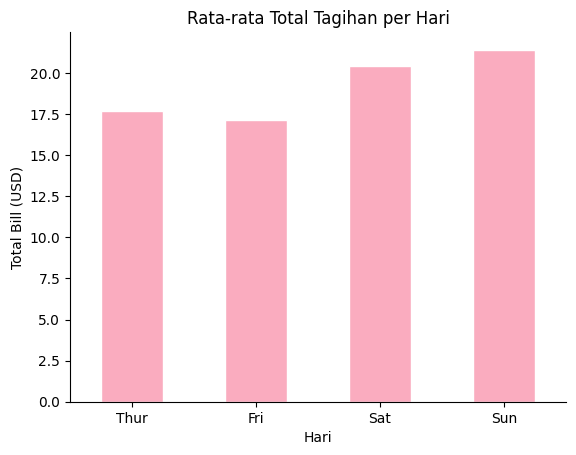

In [35]:
# 3. GRAFIK 1 : Bar Chart
fig, ax1 = plt.subplots()

#avg_by_day = df.groupby('day')['total_bill'].mean()
avg_by_day = df.groupby('day', observed=True)['total_bill'].mean()
avg_by_day.plot(kind='bar', ax=ax1, color='#FAACBF', edgecolor='white')

ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top','right']].set_visible(False)

plt.show()

In [49]:
# 4. GRAFIK 2 : Histogram + KDE
sns.histplot(data=df, x='total_bill', hue='time', kde=True, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Total Tagihan per Waktu Makan')
ax2.spines[['top','right']].set_visible(False)

# 5. GRAFIK 3: Boxplot
sns.boxplot(data=df, x='day', y='total_bill', hue='sex', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Tagihan per Hari & Gender')
ax3.spines[['top','right']].set_visible(False)

# 6. GRAFIK 4: Scatter Plot
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time', size='size', sizes=(30,180), palette='Set2', alpha=0.7, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip', scatter=False, color='gray', ax=ax4)
ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)')
ax4.spines[['top','right']].set_visible(False)

# 7. EKSPOR
plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_tips.png')

<Figure size 640x480 with 0 Axes>

Dashboard tersimpan sebagai dashboard_tips.png
